# Machine Learning Assignment : Customer Segmentation & Purchase Prediction
**Name :** Kashish Agrawal

**Date :** 24/01/2026

In [ ]:
# Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Setup for nice plots
sns.set(style="whitegrid")
%matplotlib inline

## Part 1: Data Exploration and Preprocessing


### 1.1 Load and Inspect

In [2]:
# Load the dataset
df = pd.read_csv('customer_data.csv')

# Display first 10 rows of the dataset
print("First 10 rows")
df.head(10)

First 10 rows


,customer_id,age,gender,city_tier,membership_type,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
0,CUST000878,29.0,Female,Tier 3,Silver,465.00,11,42.27,50.0,18.0,4,15.53,0
1,CUST004886,47.0,Male,Tier 1,Platinum,4451.32,23,193.54,16.0,38.0,6,404.45,1
2,CUST002485,37.0,Male,Tier 1,Platinum,1903.02,21,90.62,29.0,28.0,5,207.83,0
3,CUST002289,37.0,Male,Tier 1,Platinum,3952.75,23,171.86,33.0,31.0,11,502.30,1
4,CUST000812,25.0,Male,Tier 1,Silver,1367.07,11,124.28,46.0,18.0,7,70.93,0
5,CUST000249,36.0,Female,Tier 2,Silver,160.15,6,26.69,39.0,8.0,3,8.96,0
6,CUST003299,32.0,Male,Tier 2,Gold,3440.79,17,202.40,29.0,29.0,6,304.40,1
7,CUST000107,37.0,Female,Tier 1,Silver,505.17,6,84.20,51.0,15.0,4,16.93,0
8,CUST000280,26.0,Female,Tier 3,Silver,2476.96,9,275.22,44.0,10.0,4,71.01,0
9,CUST001282,27.0,NaN,Tier 1,Silver,404.24,12,33.69,56.0,17.0,8,26.07,0


In [3]:
# Check the shape of the dataset
print("Shape of Dataset:", df.shape)

Shape of Dataset: (5025, 13)


In [4]:
# Info and Types
print("\nDataset Info:")
df.info()



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   5025 non-null   object 
 1   age                           4723 non-null   float64
 2   gender                        4724 non-null   object 
 3   city_tier                     5025 non-null   object 
 4   membership_type               5025 non-null   object 
 5   total_spend                   5025 non-null   float64
 6   num_transactions              5025 non-null   int64  
 7   avg_transaction_value         5025 non-null   float64
 8   days_since_last_purchase      4723 non-null   float64
 9   num_visits                    4724 non-null   float64
 10  product_categories_purchased  5025 non-null   int64  
 11  discount_used                 5025 non-null   float64
 12  high_value_customer           5025 non-null   i

In [5]:
# Summary statistics
print("\nSummary Statistics:")
df.describe()


Summary Statistics:


,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
count,4723.000000,5025.000000,5025.000000,5025.000000,4723.000000,4724.000000,5025.000000,5025.000000,5025.000000
mean,39.279483,3520.270324,15.047761,219.407385,29.456490,23.032599,6.714030,308.958681,0.373731
std,11.608329,3503.705187,7.628706,167.171094,13.163085,10.362527,3.162972,373.824281,0.483842
min,18.000000,11.590000,1.000000,1.770000,4.000000,3.000000,1.000000,0.430000,0.000000
25%,30.000000,1031.970000,9.000000,99.830000,19.000000,15.000000,4.000000,61.530000,0.000000
50%,38.000000,2258.380000,14.000000,176.020000,26.000000,21.000000,6.000000,166.820000,0.000000
75%,47.000000,4777.600000,20.000000,291.620000,41.000000,30.000000,9.000000,405.600000,1.000000
max,75.000000,27621.780000,43.000000,1500.110000,69.000000,59.000000,15.000000,3999.660000,1.000000


### 1.2 Handle Missing Values

In [6]:
# Identify columns with missing values
missing_values = df.isnull().sum()
print("Missing values before handling:")
print(missing_values[missing_values > 0])

Missing values before handling:
age                         302
gender                      301
days_since_last_purchase    302
num_visits                  301
dtype: int64


In [7]:
# Fill numerical column's missing values with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical column's missing values with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify that no missing values remain
print("\nMissing values after handling:")
print(df.isnull().sum().sum())


Missing values after handling:
0


### 1.3 Handle Duplicates

In [8]:
# Check for duplicate rows based on customer_id
initial_rows = df.shape[0]
duplicates = df.duplicated(subset=['customer_id']).sum()

# Remove duplicate rows
df.drop_duplicates(subset=['customer_id'], inplace=True)
final_rows = df.shape[0]

# Report
print(f"Initial number of rows: {initial_rows}")
print(f"Number of duplicates removed: {duplicates}")
print(f"Final number of rows: {final_rows}")

Initial number of rows: 5025
Number of duplicates removed: 25
Final number of rows: 5000


### 1.4 Exploratory Analysis

In [9]:
# Distribution of categorical variables
print("Gender Distribution:\n", df['gender'].value_counts())
print("\nMembership Type Distribution:\n", df['membership_type'].value_counts())
print("\nHigh Value Customer Distribution:\n", df['high_value_customer'].value_counts())

Gender Distribution:
 gender
Female    2639
Male      2292
Other       69
Name: count, dtype: int64

Membership Type Distribution:
 membership_type
Silver      1959
Gold        1911
Platinum    1130
Name: count, dtype: int64

High Value Customer Distribution:
 high_value_customer
0    3129
1    1871
Name: count, dtype: int64


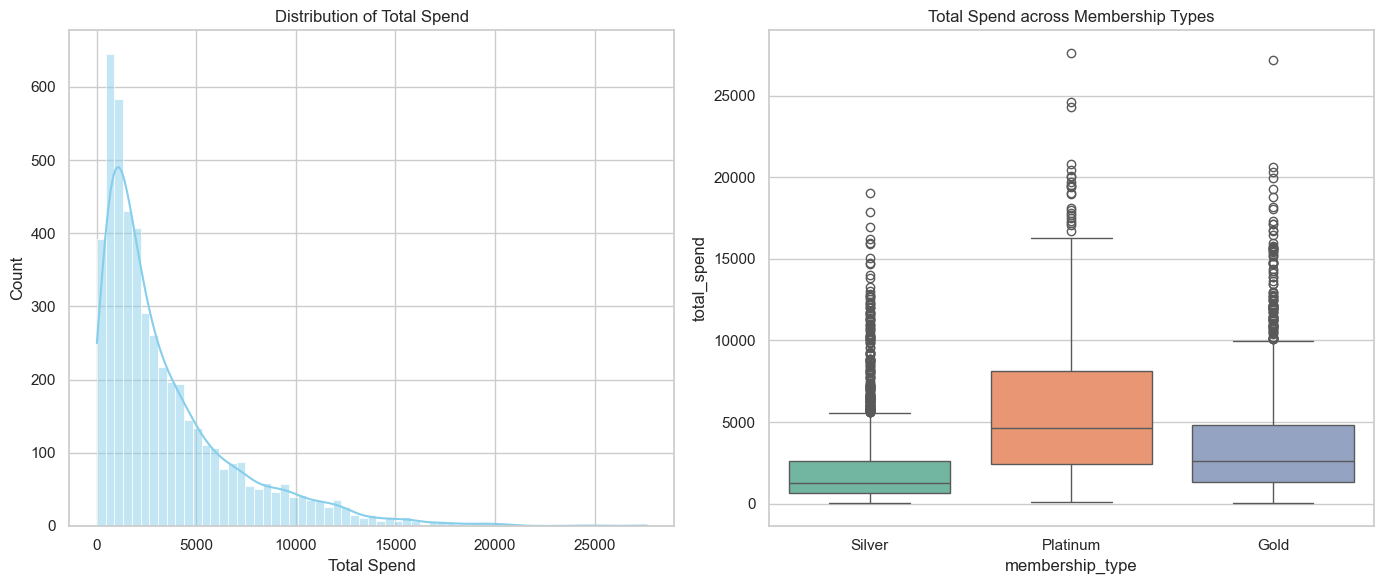

In [10]:
# Visualizations
plt.figure(figsize=(14, 6))

# Histogram for distribution of Total Spend
plt.subplot(1, 2, 1)
sns.histplot(df['total_spend'], kde=True, color='skyblue')
plt.title('Distribution of Total Spend')
plt.xlabel('Total Spend')

# Box Plot for Total Spend by Membership Type
plt.subplot(1, 2, 2)
sns.boxplot(x='membership_type', y='total_spend', data=df, hue='membership_type', palette='Set2', legend=False)
plt.title('Total Spend across Membership Types')

plt.tight_layout()
plt.show()


**Observations** 

1. **Total Spend Distribution:** The total_spend histogram shows a strong right-skewed distribution. While a large majority of customers spend a relatively small amount (concentrated between 0 and 5,000), there is a "long tail" of high-spenders reaching up to 25,000+.

2. **Membership Tiers :** There is a clear correlation between membership_type and spending. The box plot reveals that `Platinum` members have a significantly higher median spend compared to `Gold` and `Silver` members. Additionally, all three categories show a large number of outliers, indicating exceptional high-value customers in every tier.

3. **Target Variable Balance :** The high_value_customer distribution shows that the dataset is somewhat imbalanced. There are 3,129 low-value customers (labeled 0) compared to 1,871 high-value customers (labeled 1). This is a critical observation for Part 3, as the predictive model will need to learn from these two distinct groups.


## Part 2: Customer Segmentation 

### 2.1 Prepare Data for Clustering

In [11]:
# Select numerical features for customer segmentation
features = ['age','total_spend', 'num_transactions', 'avg_transaction_value', 'days_since_last_purchase', 'num_visits']
X_clustering = df[features].copy()

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Check the scaled data
print("Data scaled successfully.")

Data scaled successfully.


**Why Scaling is necessary**

Clustering algorithms like K-Means rely on calculating distances (Euclidean distance) between data points. Without scaling, features with large numerical ranges (like `total_spend` in the thousands) would dominate features with small ranges (like `num_visits` in tens), leading to biased clusters determined almost entirely by spend.

### 2.2 Determine Optimal K

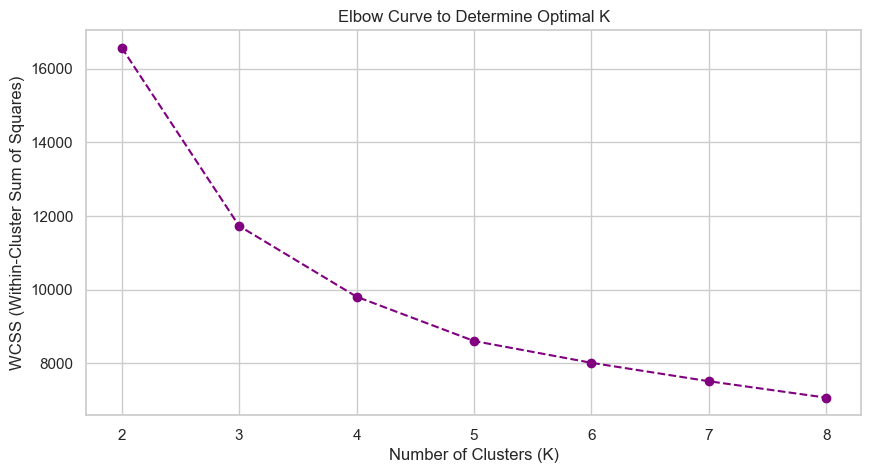

In [12]:
# Implement K-means clustering for k values ranging from 2 to 8
wcss = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    # Calculate the Within-Cluster Sum of Squares 
    wcss.append(kmeans.inertia_)

# Create the Elbow Curve Plot
plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='purple')
plt.title('Elbow Curve to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.show()

**K value :** 3

**Reasoning for K :**
I have chosen K=3. Because looking at the Elbow Curve, the sharpest decrease in Within-Cluster Sum of Squares(WCSS) happens between K=2 and K=3, the curve begins to flatten out, indicating that adding more clusters provides diminishing returns in explaining the variance.

### 2.3 Apply K-means and Profile Segments

In [13]:
# Apply K-Means with Optimal K=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['customer_segment'] = kmeans.fit_predict(X_scaled)

# Display count of customers in each cluster
print("Customer count per cluster:\n", df['customer_segment'].value_counts().sort_index())

# Calculate mean values for each cluster
cluster_profile = df.groupby('customer_segment')[features].mean()
print("\nCluster Profiles (Average Values):")
display(cluster_profile)

Customer count per cluster:
 customer_segment
0    2101
1    1145
2    1754
Name: count, dtype: int64

Cluster Profiles (Average Values):


,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits
customer_segment,,,,,,
0,41.872442,2930.763646,15.306045,206.677282,24.171347,23.265588
1,50.655895,8460.626166,25.358079,355.922707,16.229694,36.529258
2,28.529647,1002.440644,7.969213,145.877919,43.842075,13.559293


**Customer Segment Profiles**

- **Segment 0 (The Mid-Tier Regulars):** 
This is the largest group with 2101 customers. They have moderate spending (2930.76) and an average of 15 transactions. They are the customers with moderate average transaction value (206.68) and number of visits(23.26). They represent the "reliable" core of the customer base with middle-of-the-road activity levels.

- **Segment 1 (The High-Value Loyalists):**
This group is the smallest with 1145 customers.They have the highest average total spend (8460.63) and number of transactions (25.36). They are also the oldest group (average age of 50) and have the highest average transaction value(355.92). This group also have highest number of visits(36.52). These are the most profitable customers.

- **Segment 2 (The Young/Budget Explorers) :**
This group is the youngest (average age of 28) and has the lowest total spend (1002.44) and fewest number of transactions (7.97). They also have not purchased recently compared to others. They are likely the new customers or low-frequency shoppers with the lowest average transaction value(145.88). 

## Part 3 : Predictive Modeling

### 3.1 Feature Engineering

In [14]:
# Create new feature 'spend_per_visit'
df['spend_per_visit'] = df['total_spend'] / df['num_visits']

# Create new feature ' discount_percentage'
df['discount_percentage'] = df['discount_used'] / df['total_spend'] 

# Handle potential division by zero or NaN values if total_spend is zero
df['discount_percentage'] = df['discount_percentage'].fillna(0)

# Check the new features
print("\nNew Features Added:")
print(df[['spend_per_visit', 'discount_percentage']].head())



New Features Added:
   spend_per_visit  discount_percentage
0        25.833333             0.033398
1       117.140000             0.090861
2        67.965000             0.109211
3       127.508065             0.127076
4        75.948333             0.051885


**Why these features are useful**

1. **`spend_per_visit`:**
This feature helps identify high-value efficiency regardless of visit frequency. A customer who spends $500 in 1 visit is very different from one who spends $500 over 50 visits.

2. **`discount_percentage`**
This feature acts as a proxy for price sensitivity. High discount usage might indicate a customer who only buys during sales, which is a crucial behavioral signal. 

### 3.2 Data Preparation

In [15]:
# Seprate features (x) and target (y)
numerical_features = ['age', 'total_spend', 'num_transactions', 'avg_transaction_value', 
                      'days_since_last_purchase', 'num_visits', 'spend_per_visit', 'discount_percentage',
                      'product_categories_purchased', 'discount_used']
categorical_features = ['gender', 'membership_type', 'city_tier']

X = df[numerical_features + categorical_features]
y = df['high_value_customer']

# One-Hot Encoding for categorical features
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Split the data into training(80%) and testing(20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Apply Standard Scaling to numerical features
scaler = StandardScaler()
# Fit the scaler only on training data to avoid data leakage
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Data preparation complete.")
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)



Data preparation complete.
Training shape: (4000, 16)
Testing shape: (1000, 16)


### 3.3 Build Model

In [16]:
# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Model
rf_model.fit(X_train, y_train)

# Generate Predictions
y_pred = rf_model.predict(X_test)

print("Model training complete.")

Model training complete.


**Justification for Model choice**

I choose the *Random Forest Classifier* because it is an ensemble model that handles the interactions between mixed categorical and numerical features very effectively. It is robust against overfitting and provides insights into feature importance, allowing us to see which behaviours most strongly predict a high-value customer.

### 3.4 Model Evaluation

In [17]:
# Calculate metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Low-Value(0)', 'High-Value(1)']))

Confusion Matrix:
 [[623   3]
 [  3 371]]

Accuracy: 0.9940
Precision: 0.9920
Recall: 0.9920
F1 Score: 0.9920

Classification Report:

               precision    recall  f1-score   support

 Low-Value(0)       1.00      1.00      1.00       626
High-Value(1)       0.99      0.99      0.99       374

     accuracy                           0.99      1000
    macro avg       0.99      0.99      0.99      1000
 weighted avg       0.99      0.99      0.99      1000



**Interpretation of Results**

The Random Forest model performs exceptionally well with an Accuracy of 99.40% and an F1-Score of 0.9920, indicating it is highly reliable at distinguishing customer segments. For this business problem, Recall (0.9920) is likely the most critical metric because missing a potential high-value customer represents a greater lost opportunity for the marketing team than misidentifying a low-value one. Overall, the model is highly effective and ready to support data-driven retention strategies.

## Part 4 : Optimization & Insights

### 4.1 Hyperparameter Tuning

In [18]:
# Define parameter grid for Randon Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Grid Search with Cross Validation
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='f1',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

# Report the best parameters found
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1-Score:", grid_search.best_score_)

# Evaluate the tuned model on test data
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

# Compare Performance
comparison_data = {
    'Metric': ['Accuracy', 'F1-Score'],
    'Before Tuning': [f"{accuracy_score(y_test, y_pred):.4f}", f"{f1_score(y_test, y_pred):.4f}"],
    'After Tuning': [f"{accuracy_score(y_test, y_pred_tuned):.4f}", f"{f1_score(y_test, y_pred_tuned):.4f}"]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison")
display(comparison_df)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation F1-Score: 0.9909956396582343

Model Performance Comparison


,Metric,Before Tuning,After Tuning
0,Accuracy,0.9940,0.9930
1,F1-Score,0.9920,0.9906


### 4.2 Feature Importance

                    Feature  Importance
1               total_spend    0.472518
9             discount_used    0.168130
2          num_transactions    0.095295
6           spend_per_visit    0.081164
3     avg_transaction_value    0.070627
5                num_visits    0.064169
4  days_since_last_purchase    0.016897
0                       age    0.015153


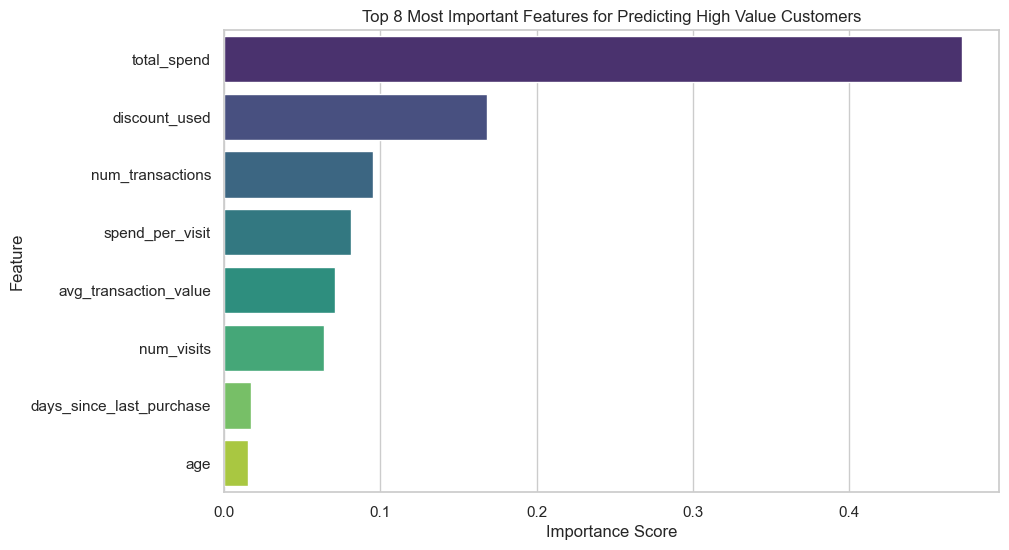

In [19]:
# Extract feature importance
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(8)

# Display feature importance
print(feature_imp_df)

# Horizontal Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top 8 Most Important Features for Predicting High Value Customers')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

**Feature Importance Interpretation**

The analysis reveals that `total_spend` is the most dominant predictor of the high-value customer, indicating that historical revenue remains the primary indicator of future loyalty. The high importance of `discount_used` suggests that this segment is highly responsive to the promotional offers, providing a clear opportunity for targeted marketing campaigns to drive retention. Transactional frequency and spending efficiency (`num_transactions` and `spend_per_visit`) also play significant roles, suggesting the business should prioritize engaging customers who visits frequently and maintain a high average basket size.

### 4.3 Business Recommendations

****1. Recommendation from Clustering Insights: Targeted Engagement for "Cluster 2 (The Young/Budget Explorers)"****

- **Observation:** Analysis of Cluster centroids (Task 2.3) reveals that Cluster 2 represents a distinct demographic of younger customers (average age ~28) with the lowest visit frequency and total spend. This segment is currently under-monetized compared to the older, frequent shoppers in Cluster 1.

- **Strategic Recommendation:** Implement a "Habit-Formation" Marketing Campaign specifically targeting this younger demographic. Since their visit frequency is low, the business should utilize push notifications and time-sensitive "Flash sales" to encourage daily app engagement. Converting this segment from "low frequency" to "moderate frequency" is the most effective pathway to migrating them into the higher-value clusters.

****2. Recommendation from Model Predictions: Operationalizing High-Precision Scoring****

- **Observation:** The Random Forest Classifier (Task 3.4) achieved a Precision score of 99% on the test set. This indicates an extremely low False Positive rate, meaning the model almost never incorrectly labels a low-value customer as high-value.

- **Strategic Recommendation:** Deploy this model into the live CRM(Customer Relationship Management) pipeline to strictly automate "VIP Fast-Tracking" when a new customer is predicted as "High-Value" (Class 1) early in their lifecycle, the system should automatically unlock "Gold Tier" benefits (e.g., free shipping) for their next purchase. Because the model's precision is high, the risk of "wasting" these expensive benefits on non-profitable customers is negligible, allowing the aggressive retention strategies.

****3. Recommendation from Feature Importance: Prioritizing Average Order Value (AOV)****

- **Observation:** The Feature Importance Analysis (Task 4.2) highlights that `avg_transaction_value` and `spend_per_visit` are among the most significant predictors of customer value, ranking higher than `num_visits` or `age`.

- **Strategic Recommendation:** Shift the merchandising strategy to focus on maximizing Average Order Value (AOV) rather than just visit frequency. Implement "bundle pricing" and "threshold discounts" (e.g., "Spend $50 more to save 10%") at checkout. This tactic directly incentivizes customers to increase their basket size per transaction, which the model indicates is a primary driver for migrating customers into the "High Value" segment.